In [1]:
import numpy as np
import pandas as pd

In [4]:
#read toy dataset
df = pd.read_csv('/content/placement.csv')

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [7]:
df.shape

(100, 4)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [11]:
#preprocessing
df = df.iloc[:,1:]

In [12]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


/tmp/ipykernel_2262/2139641890.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


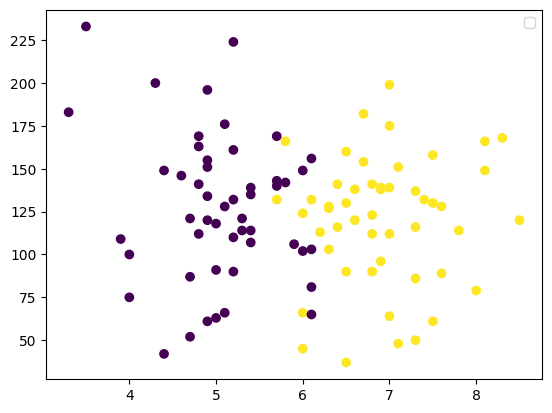

In [16]:
#EDA
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c= df['placement'])

In [18]:
#Feature selection
# no need to do in toy dataset

In [25]:
#Extract input and output cols
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [29]:
X


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [30]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [32]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [33]:
X_train

,cgpa,iq
91,7.5,158.0
14,6.1,103.0
67,5.0,118.0
24,4.7,121.0
79,6.5,90.0
...,...,...
94,4.7,52.0
23,4.7,87.0
44,7.5,61.0
61,7.3,137.0


In [34]:
y_train

,placement
91,1
14,0
67,0
24,0
79,1
...,...
94,0
23,0
44,1
61,1


In [35]:
X_test

,cgpa,iq
34,4.8,163.0
40,4.9,134.0
97,6.7,182.0
52,7.0,175.0
19,5.2,132.0
32,7.0,139.0
56,6.1,65.0
36,5.7,140.0
43,6.8,141.0
73,4.9,61.0


In [36]:
#Scalimg
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
X_train

array([[ 1.28961535e+00,  8.93742746e-01],
       [ 8.59743567e-02, -4.91362637e-01],
       [-8.59743567e-01, -1.13606623e-01],
       [-1.11766664e+00, -3.80554206e-02],
       [ 4.29871784e-01, -8.18751182e-01],
       [ 6.87794854e-01, -2.64709029e-01],
       [ 6.01820497e-01,  7.93007809e-01],
       [ 1.11766664e+00, -9.19486118e-01],
       [ 1.80546149e+00,  1.09521262e+00],
       [-9.45717924e-01,  7.17456606e-01],
       [ 8.59743567e-01,  1.92627585e+00],
       [-6.87794854e-01, -3.15076497e-01],
       [ 1.37558971e+00,  1.38230719e-01],
       [ 9.45717924e-01, -1.87646802e+00],
       [ 1.71948713e+00, -1.09577226e+00],
       [-1.46156406e+00,  1.95145958e+00],
       [ 8.59743567e-01, -1.47352827e+00],
       [ 1.71948713e-01, -2.39525294e-01],
       [ 1.20364099e+00,  2.38965656e-01],
       [ 7.73769210e-01, -6.67648776e-01],
       [-7.73769210e-01,  1.34704996e+00],
       [ 4.29871784e-01, -2.15348910e+00],
       [ 7.63605683e-16, -1.42316080e+00],
       [ 2.

In [38]:
X_test

array([[-1.03169228,  1.01966142],
       [-0.94571792,  0.28933312],
       [ 0.6018205 ,  1.49815237],
       [ 0.85974357,  1.32186623],
       [-0.68779485,  0.23896566],
       [ 0.85974357,  0.4152518 ],
       [ 0.08597436, -1.44834454],
       [-0.25792307,  0.44043553],
       [ 0.68779485,  0.46561926],
       [-0.94571792, -1.54907947]])

In [39]:
#Train the model
from sklearn.linear_model import LogisticRegression
mymodel = LogisticRegression()
mymodel.fit(X_train,y_train)

LogisticRegression()

In [40]:
#  Evaluate the model/model selection
y_pred = mymodel.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9

<Axes: >

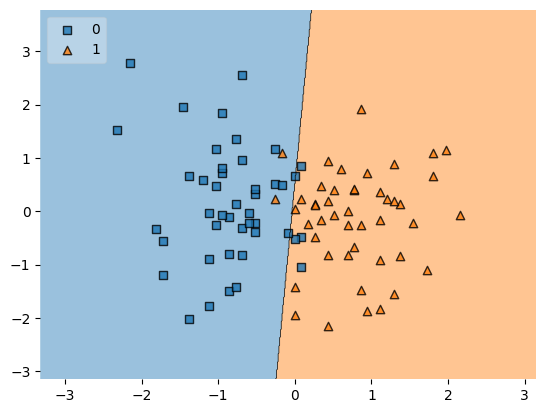

In [41]:
# visualization of dicision boundary
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,y_train.values,clf = mymodel,legend =2) # .values convert to array, clf means classifier

In [42]:
#deploy the model

import pickle

pickle.dump(mymodel,open('model.pkl','wb'))

#use heroku or aws or gcp to deploy the model